Trees

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import regex as re

Pre-processing

In [2]:
# Train-only preprocessing implementation (leakage-safe)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# Reload a fresh copy so preprocessing is reproducible and independent of EDA mutations
raw_data = pd.read_csv('training_data_202601.csv')
raw_data = raw_data.rename(columns={
    'Painting': 'painting',
    'On a scale of 1–10, how intense is the emotion conveyed by the artwork?': 'emotion_rating',
    'Describe how this painting makes you feel.': 'feel_describe',
    'This art piece makes me feel sombre.': 'sombre',
    'This art piece makes me feel content.': 'content',
    'This art piece makes me feel calm.': 'calm',
    'This art piece makes me feel uneasy.': 'uneasy',
    'How many prominent colours do you notice in this painting?': 'colors',
    'How many objects caught your eye in the painting?': 'objects',
    'How much (in Canadian dollars) would you be willing to pay for this painting?': 'price',
    'If you could purchase this painting, which room would you put that painting in?': 'room',
    'If you could view this art in person, who would you want to view it with?': 'exhibition_with',
    'What season does this art piece remind you of?': 'season',
    'If this painting was a food, what would be?': 'food',
    'Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.': 'soundtrack'
})

likert_cols = ['sombre', 'content', 'calm', 'uneasy']


def extract_likert_value(value):
    if pd.isna(value):
        return np.nan
    match = re.match(r'^(\d+)', str(value).strip())
    return float(match.group(1)) if match else np.nan


def parse_price_value(value):
    if pd.isna(value):
        return np.nan

    text = str(value).lower().strip().replace(',', '')

    range_match = re.search(r'(\d+\.?\d*)\s*(?:-|–|to)\s*(\d+\.?\d*)', text)
    if range_match:
        low, high = float(range_match.group(1)), float(range_match.group(2))
        return (low + high) / 2

    for pattern, multiplier in [
        (r'(\d+\.?\d*)\s*(?:billion|bn|b)\b', 1_000_000_000),
        (r'(\d+\.?\d*)\s*(?:million|m)\b', 1_000_000),
        (r'(\d+\.?\d*)\s*k\b', 1_000),
    ]:
        mult_match = re.search(pattern, text)
        if mult_match:
            return float(mult_match.group(1)) * multiplier

    first_num = re.search(r'(\d+\.?\d*)', text)
    if first_num:
        return float(first_num.group(1))

    return np.nan


for col in likert_cols:
    raw_data[col] = raw_data[col].apply(extract_likert_value)

raw_data['price_clean'] = raw_data['price'].apply(parse_price_value)

if 'train_ids' not in globals() or 'test_ids' not in globals():
    rng = np.random.default_rng(42)
    unique_ids = raw_data['unique_id'].dropna().unique()
    unique_ids = np.array(unique_ids)
    rng.shuffle(unique_ids)
    split_idx = int(len(unique_ids) * 0.8)
    train_ids = set(unique_ids[:split_idx])
    test_ids = set(unique_ids[split_idx:])

train_df = raw_data[raw_data['unique_id'].isin(train_ids)].copy()
test_df = raw_data[raw_data['unique_id'].isin(test_ids)].copy()

y_train = train_df['painting'].copy()
y_test = test_df['painting'].copy()

# 1) Numeric preprocessing: median imputation -> outlier cap -> log(price) -> scaling
numeric_cols = ['emotion_rating', 'sombre', 'content', 'calm', 'uneasy', 'colors', 'objects', 'price_clean']
imputer = SimpleImputer(strategy='median')

train_num = pd.DataFrame(
    imputer.fit_transform(train_df[numeric_cols]),
    columns=numeric_cols,
    index=train_df.index
)
test_num = pd.DataFrame(
    imputer.transform(test_df[numeric_cols]),
    columns=numeric_cols,
    index=test_df.index
)

price_cap = np.nanquantile(train_num['price_clean'], 0.99)
train_num['price_clean'] = np.clip(train_num['price_clean'], 0, price_cap)
test_num['price_clean'] = np.clip(test_num['price_clean'], 0, price_cap)

train_num['price_clean'] = np.log1p(train_num['price_clean'])
test_num['price_clean'] = np.log1p(test_num['price_clean'])

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_num)
X_test_num = scaler.transform(test_num)

# 2) Multi-label categorical preprocessing: comma split -> multi-hot encoding
multilabel_cols = ['room', 'exhibition_with', 'season']


def split_labels(value):
    if pd.isna(value):
        return []
    return [item.strip() for item in str(value).split(',') if item.strip()]


mlb_models = {}
X_train_multi_parts = []
X_test_multi_parts = []
for col in multilabel_cols:
    mlb = MultiLabelBinarizer()
    train_labels = train_df[col].apply(split_labels)
    test_labels = test_df[col].apply(split_labels)

    train_multi = mlb.fit_transform(train_labels)
    test_multi = mlb.transform(test_labels)

    mlb_models[col] = mlb
    X_train_multi_parts.append(csr_matrix(train_multi))
    X_test_multi_parts.append(csr_matrix(test_multi))

# 3) Text preprocessing: combine text columns -> TF-IDF
text_cols = ['feel_describe', 'food', 'soundtrack']
train_text = train_df[text_cols].fillna('').agg(' '.join, axis=1)
test_text = test_df[text_cols].fillna('').agg(' '.join, axis=1)

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_features=2000
)
X_train_text = tfidf.fit_transform(train_text)
X_test_text = tfidf.transform(test_text)

# Final design matrix
X_train = hstack([csr_matrix(X_train_num), *X_train_multi_parts, X_train_text], format='csr')
X_test = hstack([csr_matrix(X_test_num), *X_test_multi_parts, X_test_text], format='csr')

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Target classes:', sorted(y_train.unique()))
print('TF-IDF vocabulary size:', len(tfidf.vocabulary_))
print('Price cap (train 99th percentile):', round(float(price_cap), 2))

Train shape: (1347, 2022)
Test shape: (339, 2022)
Target classes: ['The Persistence of Memory', 'The Starry Night', 'The Water Lily Pond']
TF-IDF vocabulary size: 2000
Price cap (train 99th percentile): 227000000.0


In [3]:
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import json

train_groups = train_df['unique_id'].values

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

gkf = GroupKFold(n_splits=5)

Baseline: Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

logreg_param_grid = {
    'C': [100, 10, 1, 0.1, 0.01]
}

logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ),
    param_grid=logreg_param_grid,
    cv=gkf,
    scoring='accuracy',
    n_jobs=2,
    verbose=1
)

logreg_grid_search.fit(X_train, y_train_encoded, groups=train_groups)

print(f"Best LR Params: {logreg_grid_search.best_params_}")
print(f"Best LR CV Score: {logreg_grid_search.best_score_:.4f}")

best_lr = logreg_grid_search.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best LR Params: {'C': 10}
Best LR CV Score: 0.8723


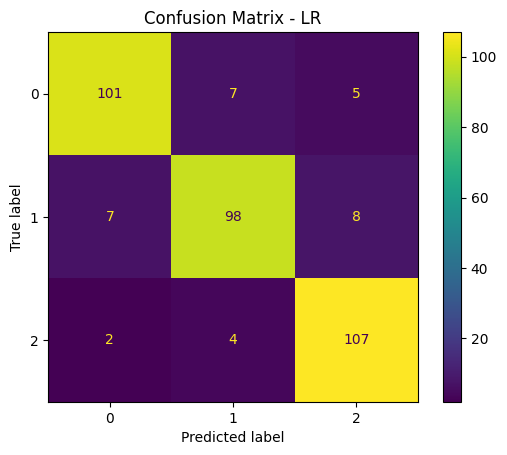

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = best_lr.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test_encoded, y_pred)
plt.title("Confusion Matrix - LR")
plt.show()

Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, 50, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4],
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=gkf,
    scoring='accuracy',
    n_jobs=2,
    verbose=1
)

rf_grid_search.fit(X_train, y_train_encoded, groups=train_groups)

print(f"Best RF Params: {rf_grid_search.best_params_}")
print(f"Best RF CV Score: {rf_grid_search.best_score_:.4f}")

best_rf = rf_grid_search.best_estimator_

Fitting 5 folds for each of 405 candidates, totalling 2025 fits
Best RF Params: {'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best RF CV Score: 0.8857


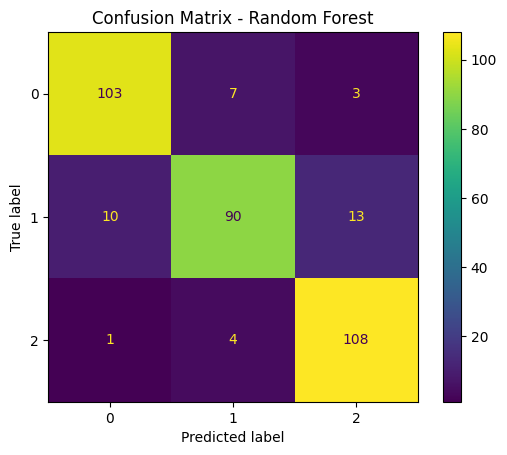

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = best_rf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test_encoded, y_pred)
plt.title("Confusion Matrix - Random Forest")
plt.show()

XGBoost

In [15]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

xgb_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 5],
    'reg_alpha': [0, 0.1],
}

xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=xgb_param_grid,
    cv=gkf,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train_encoded, groups=train_groups)

print(f"Best XGB Params: {xgb_grid_search.best_params_}")
print(f"Best XGB CV Score: {xgb_grid_search.best_score_:.4f}")

best_xgb = xgb_grid_search.best_estimator_

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': 0}
Best XGB CV Score: 0.8790


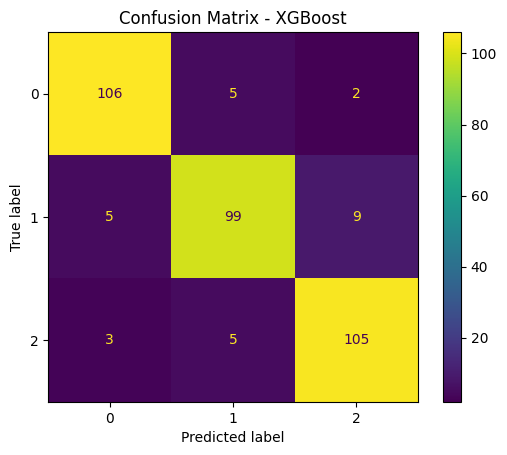

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = best_xgb.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test_encoded, y_pred)
plt.title("Confusion Matrix - XGBoost")
plt.show()